# Trace CDF 2D Histogram

This notebook loads `/data/rcnp2025/run_1056_cdf.npy` and renders a 2D histogram with a log-scaled color axis.

- if the file already contains a 2D histogram, it is plotted directly
- if the file contains per-trace CDF samples, the notebook bins them into a 2D histogram first


In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np

input_path = Path("/data/rcnp2025/trace_label/run_1056_cdf.npy")
default_thresholds = np.array([10, 20, 30, 40, 50, 60, 100, 150, 200, 250], dtype=np.float64)
value_edges = np.linspace(0.0, 1.0, 101, dtype=np.float64)

print(input_path)


/data/rcnp2025/trace_label/run_1056_cdf.npy


In [4]:
def _threshold_edges(centers: np.ndarray) -> np.ndarray:
    centers = np.asarray(centers, dtype=np.float64)
    if centers.ndim != 1 or centers.size == 0:
        raise ValueError("threshold centers must be a non-empty 1D array")
    if centers.size == 1:
        return np.array([centers[0] - 0.5, centers[0] + 0.5], dtype=np.float64)

    midpoints = (centers[:-1] + centers[1:]) / 2.0
    first_edge = centers[0] - (midpoints[0] - centers[0])
    last_edge = centers[-1] + (centers[-1] - midpoints[-1])
    return np.concatenate(([first_edge], midpoints, [last_edge]))

if not input_path.is_file():
    raise FileNotFoundError(f"input file not found: {input_path}")

payload = np.load(input_path, allow_pickle=True)
array = np.asarray(payload)

if array.ndim != 2:
    raise ValueError(f"expected a 2D array, got shape {array.shape}")

if np.issubdtype(array.dtype, np.integer):
    histogram = array.astype(np.int64, copy=False)
    threshold_centers = np.arange(1, histogram.shape[0] + 1, dtype=np.float64)
    source_kind = "histogram"
else:
    samples = array.astype(np.float64, copy=False)
    threshold_count = samples.shape[1]
    if threshold_count == len(default_thresholds):
        threshold_centers = default_thresholds
    else:
        threshold_centers = np.arange(1, threshold_count + 1, dtype=np.float64)

    x_positions = np.broadcast_to(threshold_centers, samples.shape)
    valid = np.isfinite(samples)
    valid &= samples >= 0.0
    valid &= samples <= 1.0
    if not np.any(valid):
        raise ValueError("input CDF samples do not contain any finite values in [0, 1]")

    histogram, _, _ = np.histogram2d(
        x_positions[valid],
        samples[valid],
        bins=[_threshold_edges(threshold_centers), value_edges],
    )
    histogram = histogram.astype(np.int64, copy=False)
    source_kind = "samples"

print(f"loaded {source_kind} with shape {array.shape}")
print(f"histogram shape: {histogram.shape}")
print(f"total count: {int(histogram.sum())}")


loaded histogram with shape (150, 100)
histogram shape: (150, 100)
total count: 2573506950


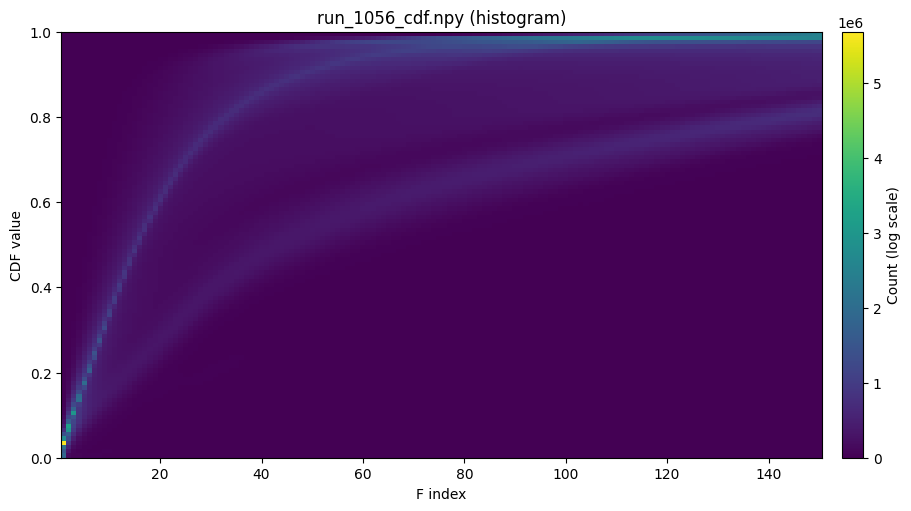

In [6]:
threshold_edges = _threshold_edges(threshold_centers)
positive = histogram[histogram > 0]
vmin = float(positive.min()) if positive.size else 1.0
vmax = max(vmin, float(histogram.max()), 1.0)

fig, ax = plt.subplots(figsize=(9, 5), constrained_layout=True)
mesh = ax.pcolormesh(
    threshold_edges,
    value_edges,
    histogram.T,
    shading="auto",
    cmap="viridis",
    # norm=LogNorm(vmin=vmin, vmax=vmax),
)
colorbar = fig.colorbar(mesh, ax=ax, pad=0.02)
colorbar.set_label("Count (log scale)")

ax.set_title(f"{input_path.name} ({source_kind})")
ax.set_xlabel("F index")
ax.set_ylabel("CDF value")
ax.set_xlim(threshold_edges[0], threshold_edges[-1])
ax.set_ylim(0.0, 1.0)

plt.show()
